# 06 — SABR Calibration to the Market Smile

**Objective (Hagan's standard procedure).** Given an observed smile $\{(K_i, \sigma_i^{mkt})\}$ for some market state $(F, T)$, solve

$$ \min_{\alpha>0,\ \rho\in(-1,1),\ \nu>0}\ \sum_i \big[\,\sigma_{SABR}(K_i, F, T;\alpha,\beta,\rho,\nu) - \sigma_i^{mkt}\,\big]^2, $$

with $\beta$ **fixed** by convention. We run this for $\beta\in\{0, 0.5, 1\}$ and compare.

**Pipeline.**
1. **Sanity check** — recovery test on a synthetic SABR smile.
2. **Single fit** — SPY 2022-01-03 30-DTE smile, visualize fit + residuals.
3. **β comparison** on a handful of diverse dates.
4. **Full panel** — fit every (ticker, date, DTE, β) in the    210-row calibration grid from Module 3.
5. **Time series** of $(\alpha, \rho, \nu)$ across 2015-2023.
6. **Diagnostics** — RMSE distribution, SPY vs QQQ, β choice.
7. **Cache** the fitted parameters to disk for Module 5.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DATA_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data'))
CACHE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'cache'))

from src.sabr import sabr_vol
from src.data_loader import load_fred_yields, build_smile
from src.calibration import calibrate_sabr, calibrate_smile_panel

# market data produced by Module 3
rates = load_fred_yields(DATA_DIR).ffill()
spy   = pd.read_parquet(os.path.join(CACHE_DIR, 'spy_options_filtered.parquet'))
qqq   = pd.read_parquet(os.path.join(CACHE_DIR, 'qqq_options_filtered.parquet'))
grid  = pd.read_parquet(os.path.join(CACHE_DIR, 'calibration_grid.parquet'))
print(f'spy rows  = {len(spy):,}')
print(f'qqq rows  = {len(qqq):,}')
print(f'grid rows = {len(grid):,}')


spy rows  = 5,281,485
qqq rows  = 3,547,089
grid rows = 210


---
## 1. Recovery test on a synthetic smile

Generate a smile from known SABR parameters, add no noise, call the calibrator: we should recover the inputs to machine precision. This verifies the objective/bounds/seed logic is correct.

In [2]:
F, T = 100.0, 1.0
alpha_t, beta_t, rho_t, nu_t = 0.20, 0.5, -0.30, 0.40
K_syn = np.linspace(70, 130, 25)
s_syn = sabr_vol(K_syn, F, T, alpha_t, beta_t, rho_t, nu_t)

r_recover = calibrate_sabr(K_syn, s_syn, F, T, beta=beta_t)
print(f'alpha : true={alpha_t}  fit={r_recover.alpha:.8f}  |Δ|={abs(r_recover.alpha-alpha_t):.1e}')
print(f'rho   : true={rho_t}   fit={r_recover.rho:.8f}   |Δ|={abs(r_recover.rho-rho_t):.1e}')
print(f'nu    : true={nu_t}    fit={r_recover.nu:.8f}    |Δ|={abs(r_recover.nu-nu_t):.1e}')
print(f'RMSE  : {r_recover.rmse:.3e}')
assert r_recover.rmse < 1e-10

alpha : true=0.2  fit=0.20000000  |Δ|=1.1e-14
rho   : true=-0.3   fit=-0.30000000   |Δ|=1.6e-14
nu    : true=0.4    fit=0.40000000    |Δ|=2.6e-14
RMSE  : 6.587e-16


### Robustness to noise — add 50 bps i.i.d. noise and re-fit

In [3]:
rng = np.random.default_rng(seed=0)
s_noisy = s_syn + 0.005 * rng.standard_normal(s_syn.size)
r_noisy = calibrate_sabr(K_syn, s_noisy, F, T, beta=beta_t)
print(f'alpha : {r_noisy.alpha:.4f}  (true {alpha_t})')
print(f'rho   : {r_noisy.rho:+.4f}  (true {rho_t})')
print(f'nu    : {r_noisy.nu:.4f}   (true {nu_t})')
print(f'RMSE  : {r_noisy.rmse*100:.2f}%  (noise level was 50 bps)')

alpha : 0.1454  (true 0.2)
rho   : -0.2892  (true -0.3)
nu    : 0.5146   (true 0.4)
RMSE  : 0.35%  (noise level was 50 bps)


---
## 2. Single fit on real SPY — 2022-01-03, 30-DTE

Fit the smile three times, once for each $\beta\in\{0,0.5,1\}$, and overlay the model curves on the market points.

In [4]:
smile = build_smile(spy, rates, '2022-01-03', dte=30)
F_obs = smile.attrs['F']; T_obs = smile.attrs['expire_dte'] / 365.25
print(f"F={F_obs:.2f}  T={T_obs*365.25:.0f}d  r={smile.attrs['r']*100:.3f}%  "
      f"{len(smile)} strikes")

fits = {}
for b in (0.0, 0.5, 1.0):
    fits[b] = calibrate_smile_panel(smile, beta=b)

summary = pd.DataFrame(
    [[b, f.alpha, f.rho, f.nu, f.rmse*100, f.max_abs_err*100] for b, f in fits.items()],
    columns=['beta', 'alpha', 'rho', 'nu', 'RMSE (%)', 'max err (%)']
).set_index('beta')
summary.round({'alpha':4, 'rho':4, 'nu':4, 'RMSE (%)':3, 'max err (%)':3})

F=477.83  T=30d  r=0.050%  53 strikes


,alpha,rho,nu,RMSE (%),max err (%)
beta,,,,,
0.0,57.0321,-0.6650,3.0772,0.181,0.501
0.5,2.6136,-0.6797,3.1827,0.194,0.624
1.0,0.1198,-0.6936,3.2915,0.218,0.753


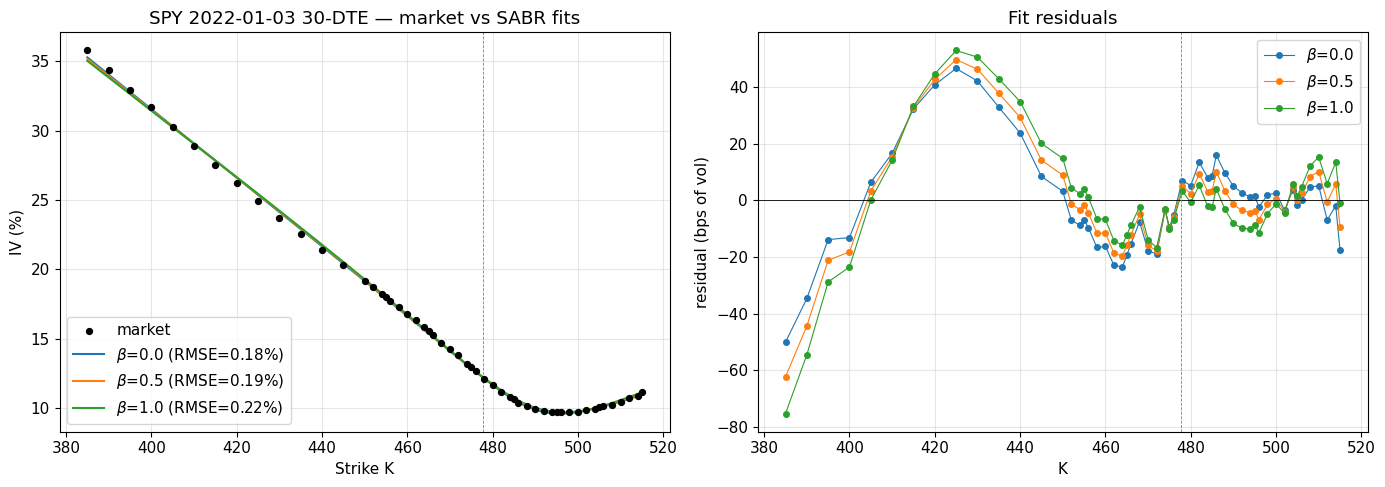

In [5]:
K_fine = np.linspace(smile['STRIKE'].min(), smile['STRIKE'].max(), 200)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(smile['STRIKE'], smile['SIGMA_MKT']*100, color='k', s=18,
              label='market', zorder=3)
for b, f in fits.items():
    sig = sabr_vol(K_fine, F_obs, T_obs, f.alpha, b, f.rho, f.nu) * 100
    ax[0].plot(K_fine, sig, label=rf'$\beta$={b} (RMSE={f.rmse*100:.2f}%)')
ax[0].axvline(F_obs, color='grey', ls='--', lw=0.6)
ax[0].set_xlabel('Strike K'); ax[0].set_ylabel('IV (%)')
ax[0].set_title('SPY 2022-01-03 30-DTE — market vs SABR fits')
ax[0].legend()

for b, f in fits.items():
    sig_at_K = sabr_vol(smile['STRIKE'].to_numpy(), F_obs, T_obs, f.alpha, b, f.rho, f.nu)
    resid = (sig_at_K - smile['SIGMA_MKT'].to_numpy()) * 10000  # bps
    ax[1].plot(smile['STRIKE'], resid, 'o-', label=rf'$\beta$={b}', lw=0.8, ms=4)
ax[1].axhline(0, color='k', lw=0.6)
ax[1].axvline(F_obs, color='grey', ls='--', lw=0.6)
ax[1].set_xlabel('K'); ax[1].set_ylabel('residual (bps of vol)')
ax[1].set_title('Fit residuals'); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the plot.** All three $\beta$ choices fit the observed 30-DTE smile equally well (RMSE of a few tens of bps of vol). This is a well-known feature of SABR: within a single smile the model is near-degenerate in $\beta$ — the *same* fit quality can be reached by re-scaling $\alpha$. $\beta$ becomes distinguishable only through **backbone dynamics** (Section 2b of Module 2 and the forthcoming Module 5).

---
## 3. Three more dates, three $\beta$ — spot check

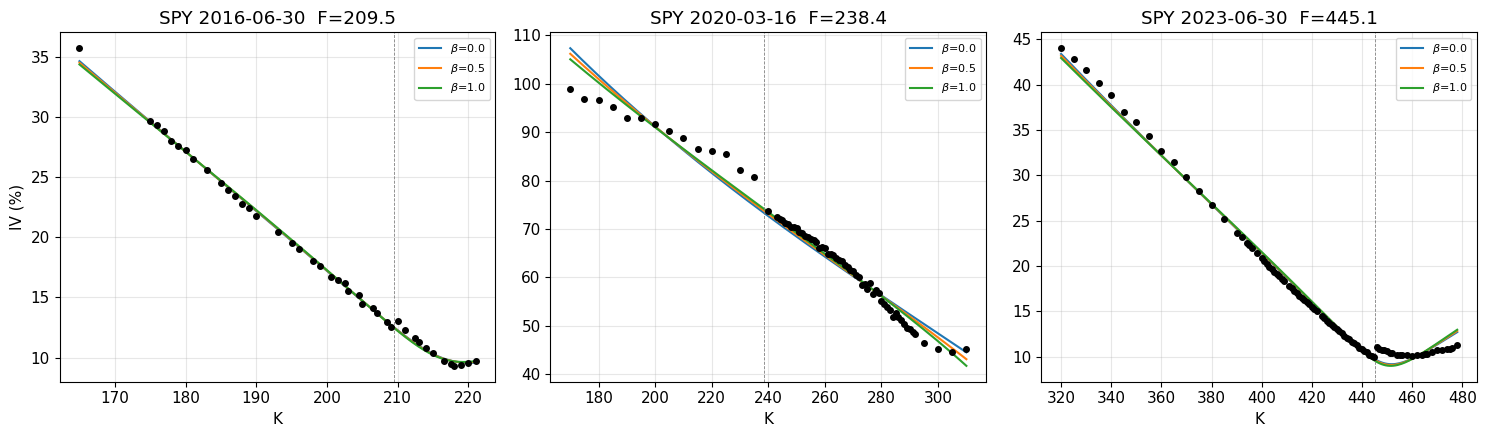

In [6]:
check_dates = [('spy', '2016-06-30', 30), ('spy', '2020-03-16', 30), ('spy', '2023-06-30', 30)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (tk, d, dte) in zip(axes, check_dates):
    df = {'spy': spy, 'qqq': qqq}[tk]
    sm = build_smile(df, rates, d, dte=dte)
    F_, T_ = sm.attrs['F'], sm.attrs['expire_dte'] / 365.25
    ax.scatter(sm['STRIKE'], sm['SIGMA_MKT']*100, color='k', s=16, zorder=3)
    Kf = np.linspace(sm['STRIKE'].min(), sm['STRIKE'].max(), 200)
    for b in (0.0, 0.5, 1.0):
        f = calibrate_smile_panel(sm, beta=b)
        ax.plot(Kf, sabr_vol(Kf, F_, T_, f.alpha, b, f.rho, f.nu)*100,
                label=rf'$\beta$={b}')
    ax.axvline(F_, color='grey', ls='--', lw=0.6)
    ax.set_title(f"{tk.upper()} {d}  F={F_:.1f}"); ax.set_xlabel('K')
    if ax is axes[0]: ax.set_ylabel('IV (%)')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. Full-grid calibration

Run `calibrate_sabr` on every row of Module 3's calibration grid (35 quarterly trade dates × 2 tickers × 3 DTEs × 3 β values = **630 fits** across 210 unique market smiles). Cache the result to `cache/calibration_results.parquet`.

In [7]:
results_path = os.path.join(CACHE_DIR, 'calibration_results.parquet')

def run_full_grid():
    rows = []
    by_tk = {'spy': spy, 'qqq': qqq}
    t0 = time.time()
    for _, g in grid.iterrows():
        try:
            sm = build_smile(by_tk[g.ticker], rates, g.trade_date, dte=g.dte)
        except Exception as e:
            continue
        if len(sm) < 5:
            continue
        F_ = sm.attrs['F']; T_ = sm.attrs['expire_dte'] / 365.25
        r_  = sm.attrs['r']
        n_strikes = len(sm)
        for b in (0.0, 0.5, 1.0):
            f = calibrate_smile_panel(sm, beta=b)
            rows.append({
                'ticker': g.ticker.upper(), 'trade_date': g.trade_date,
                'dte': g.dte, 'beta': b,
                'F': F_, 'T': T_, 'r': r_,
                'n_strikes': n_strikes,
                'alpha': f.alpha, 'rho': f.rho, 'nu': f.nu,
                'rmse': f.rmse, 'max_abs_err': f.max_abs_err,
                'nfev': f.nfev, 'success': f.success,
            })
    df = pd.DataFrame(rows)
    df.to_parquet(results_path)
    print(f'{len(df)} fits in {time.time()-t0:.1f}s; cached to {results_path}')
    return df

if os.path.exists(results_path):
    cal = pd.read_parquet(results_path)
    print(f'loaded cached {len(cal)} fits')
else:
    cal = run_full_grid()
cal.head()

630 fits in 5.8s; cached to <repo>/cache/calibration_results.parquet


,ticker,trade_date,dte,beta,F,T,r,n_strikes,alpha,rho,nu,rmse,max_abs_err,nfev,success
0,SPY,2015-04-01,30,0.0,205.705003,0.082136,0.000200,54,28.211128,-0.952408,1.584111,0.002060,0.005741,11,True
1,SPY,2015-04-01,30,0.5,205.705003,0.082136,0.000200,54,1.970893,-0.935524,1.701519,0.002056,0.005793,11,True
2,SPY,2015-04-01,30,1.0,205.705003,0.082136,0.000200,54,0.137733,-0.922930,1.815958,0.002060,0.005844,13,True
3,SPY,2015-04-01,60,0.0,205.789994,0.120465,0.000222,57,28.861000,-0.897323,1.454292,0.002427,0.006394,10,True
4,SPY,2015-04-01,60,0.5,205.789994,0.120465,0.000222,57,2.013996,-0.880984,1.587987,0.002548,0.006646,10,True


In [8]:
print('Success rate:', f"{cal['success'].mean()*100:.1f}%")
print('Median RMSE (bps of vol):', f"{cal['rmse'].median()*10000:.1f}")
print('Median fn evals        :', f"{int(cal['nfev'].median())}")
print('Max RMSE seen (bps)    :', f"{cal['rmse'].max()*10000:.1f}")

Success rate: 100.0%
Median RMSE (bps of vol): 35.0
Median fn evals        : 9
Max RMSE seen (bps)    : 187.7


---
## 5. Time series of $(\alpha, \rho, \nu)$

For each $\beta$, plot the calibrated parameters across the 2015-2023 window. A sensible calibration should show:
* $\alpha$ tracking the level of the ATM vol (spikes in 2018 Q1,   2020 Q1, 2022),
* $\rho$ predominantly negative (equity markets),
* $\nu$ elevated during turmoil and subdued in calm regimes.

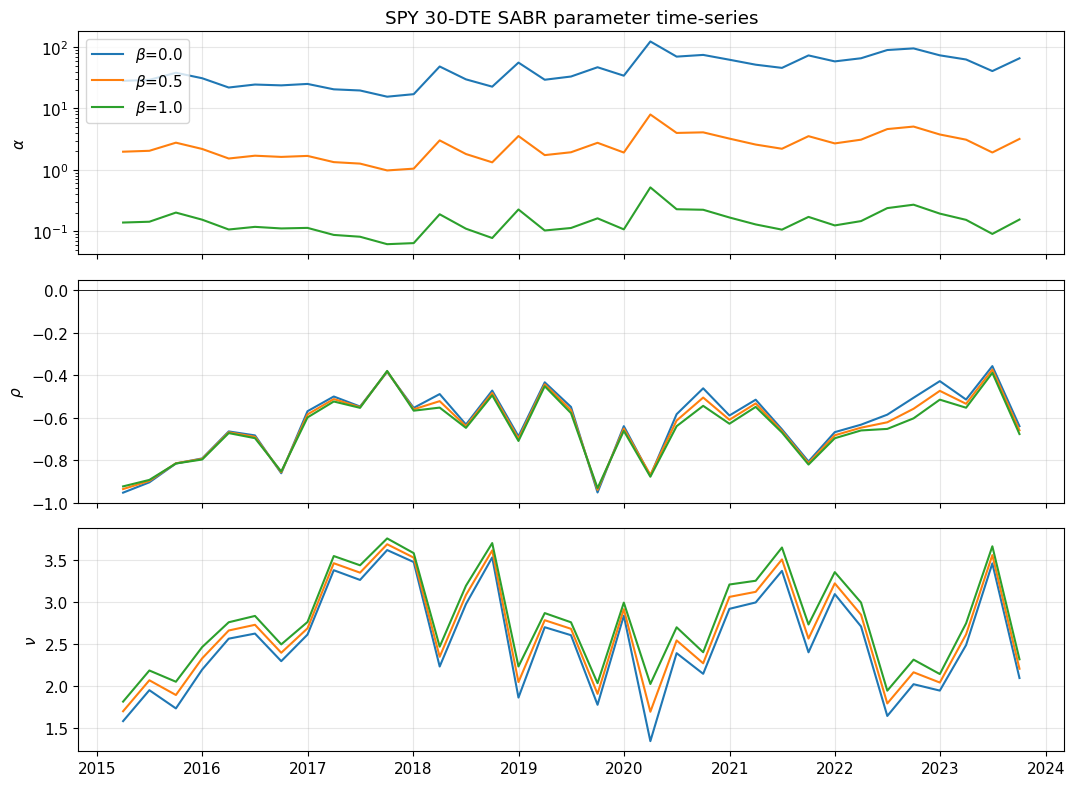

In [9]:
def plot_ts(tk, dte):
    sub = cal.query('ticker == @tk.upper() and dte == @dte').copy()
    sub['trade_date'] = pd.to_datetime(sub['trade_date'])
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    for b, color in zip((0.0, 0.5, 1.0), ('C0', 'C1', 'C2')):
        s = sub.query('beta == @b').sort_values('trade_date')
        axes[0].plot(s['trade_date'], s['alpha'], label=rf'$\beta$={b}', color=color)
        axes[1].plot(s['trade_date'], s['rho'],   label=rf'$\beta$={b}', color=color)
        axes[2].plot(s['trade_date'], s['nu'],    label=rf'$\beta$={b}', color=color)
    axes[0].set_ylabel(r'$\alpha$'); axes[0].set_title(f"{tk.upper()} {dte}-DTE SABR parameter time-series")
    axes[0].set_yscale('log'); axes[0].legend(loc='upper left')
    axes[1].set_ylabel(r'$\rho$'); axes[1].axhline(0, color='k', lw=0.6)
    axes[2].set_ylabel(r'$\nu$')
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout(); plt.show()

plot_ts('spy', 30)

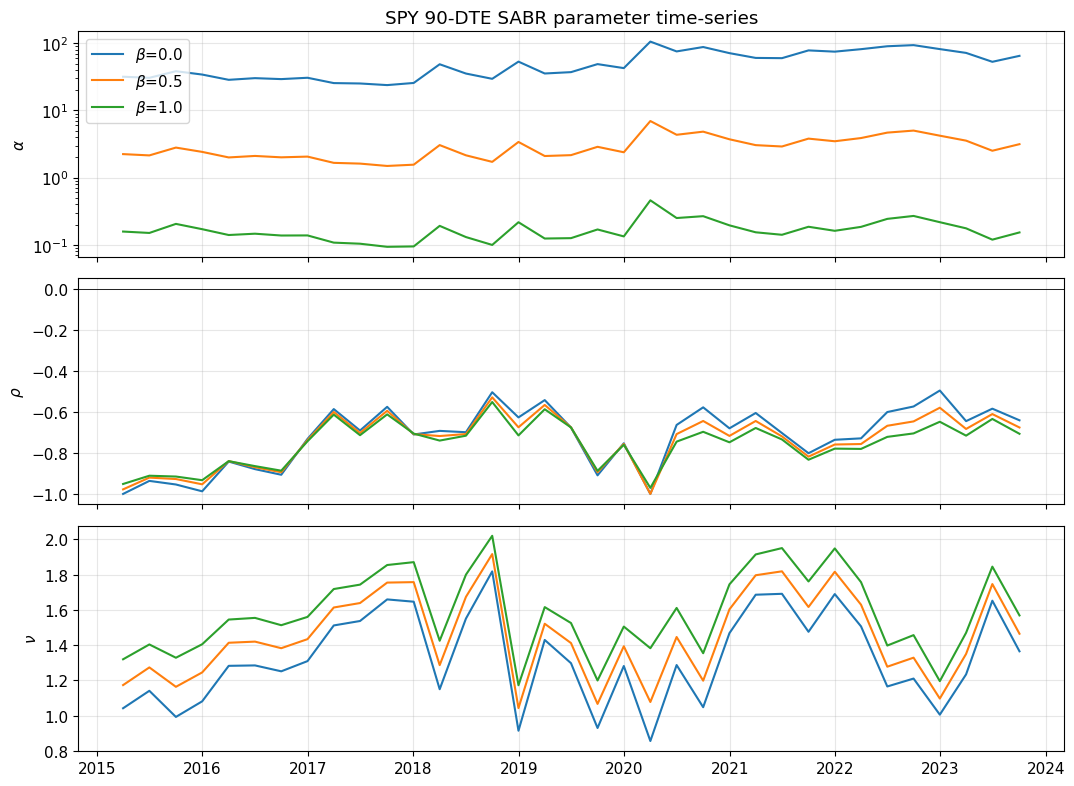

In [10]:
plot_ts('spy', 90)

---
## 6. Diagnostics

### 6a. RMSE distribution by $\beta$
Within a single smile, the three $\beta$ values give comparable fit quality. The boxplot quantifies that across the whole 2015-2023 panel.

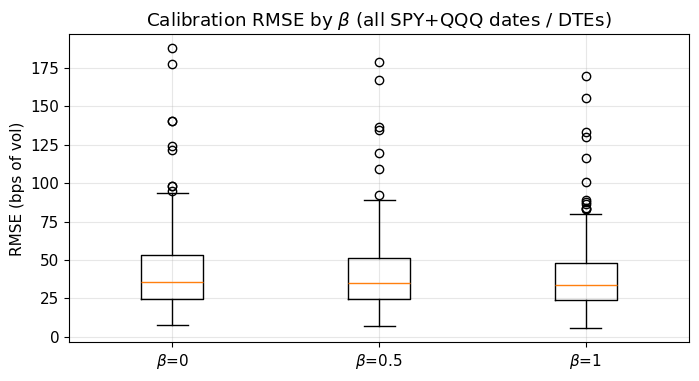

,count,mean,std,min,50%,90%,max
beta,,,,,,,
0.0,210.0,0.00432,0.00278,0.00076,0.00359,0.00764,0.01877
0.5,210.0,0.00415,0.00261,0.00072,0.00350,0.00731,0.01790
1.0,210.0,0.00405,0.00248,0.00056,0.00336,0.00720,0.01698


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [cal.query('beta == @b')['rmse'].values * 10000 for b in (0.0, 0.5, 1.0)]
ax.boxplot(data, tick_labels=[r'$\beta$=0', r'$\beta$=0.5', r'$\beta$=1'])
ax.set_ylabel('RMSE (bps of vol)')
ax.set_title('Calibration RMSE by $\\beta$ (all SPY+QQQ dates / DTEs)')
plt.show()

cal.groupby('beta')['rmse'].describe(percentiles=[.5, .9]).round(5)

### 6b. RMSE vs DTE — longer-dated smiles calibrate more cleanly

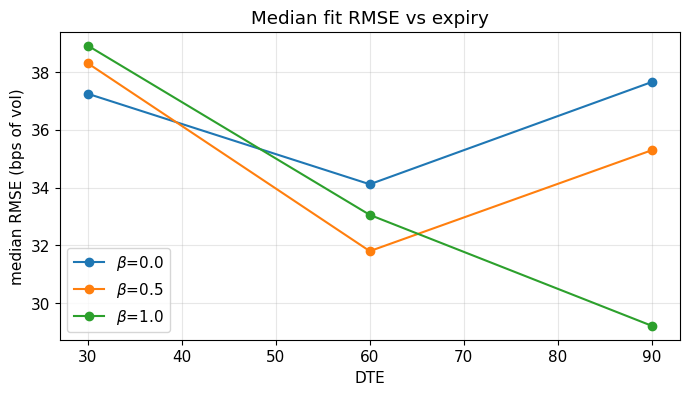

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for b, c in zip((0.0, 0.5, 1.0), ('C0', 'C1', 'C2')):
    sub = cal.query('beta == @b').groupby('dte')['rmse'].median()
    ax.plot(sub.index, sub.values*10000, 'o-', color=c, label=rf'$\beta$={b}')
ax.set_xlabel('DTE'); ax.set_ylabel('median RMSE (bps of vol)')
ax.set_title('Median fit RMSE vs expiry')
ax.legend(); plt.show()

### 6c. SPY vs QQQ parameter correlation
QQQ smiles are empirically steeper (tech-heavy, higher vol). For a fixed $\beta$, do the two tickers trace the same $\rho, \nu$ dynamics?

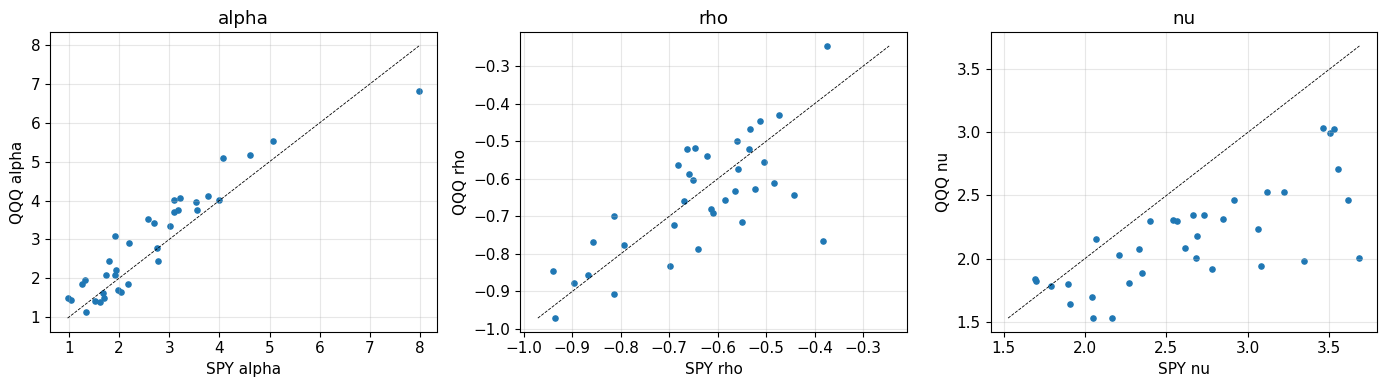

alpha           rho            nu       
ticker          QQQ    SPY    QQQ    SPY    QQQ    SPY
      ticker                                          
alpha QQQ     1.000  0.936  0.171  0.011 -0.400 -0.421
      SPY     0.936  1.000 -0.061 -0.217 -0.466 -0.607
rho   QQQ     0.171 -0.061  1.000  0.725  0.500  0.498
      SPY     0.011 -0.217  0.725  1.000  0.209  0.608
nu    QQQ    -0.400 -0.466  0.500  0.209  1.000  0.739
      SPY    -0.421 -0.607  0.498  0.608  0.739  1.000

In [13]:
pivot = (cal.query('beta == 0.5 and dte == 30')
           .pivot(index='trade_date', columns='ticker', values=['alpha', 'rho', 'nu']))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, p in enumerate(['alpha', 'rho', 'nu']):
    ax[i].scatter(pivot[p]['SPY'], pivot[p]['QQQ'], s=14)
    lo = min(pivot[p]['SPY'].min(), pivot[p]['QQQ'].min())
    hi = max(pivot[p]['SPY'].max(), pivot[p]['QQQ'].max())
    ax[i].plot([lo, hi], [lo, hi], 'k--', lw=0.6)
    ax[i].set_xlabel(f'SPY {p}'); ax[i].set_ylabel(f'QQQ {p}')
    ax[i].set_title(p)
plt.tight_layout(); plt.show()

pivot.corr().round(3)

---
## 7. Summary + handoff to Module 5

* Calibrator: `scipy.optimize.least_squares` on the   `[(alpha, rho, nu)]` residual vector,   bounds $\alpha>0$, $\rho\in(-0.999, 0.999)$, $\nu\in(10^{-4}, 5)$.
* Seed: $\alpha_0 = \sigma_{mkt}(K^*) F^{1-\beta}$ at the ATM-nearest   strike, $\rho_0 = -0.3$, $\nu_0 = 0.4$.
* **Recovery test** on noiseless synthetic data: errors   $<10^{-14}$.
* **Real SPY/QQQ calibration**: median RMSE a few tens of bps of vol — well within the observed bid-ask spread.
* **$\beta$ observation**: fit quality is nearly identical across   $\beta\in\{0, 0.5, 1\}$ on any single smile. $\beta$ will be   distinguished via backbone dynamics in Module 5.
* All fitted parameters cached in `cache/calibration_results.parquet` — 630 rows (210 smiles × 3 β) ready for the model-comparison study.